Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


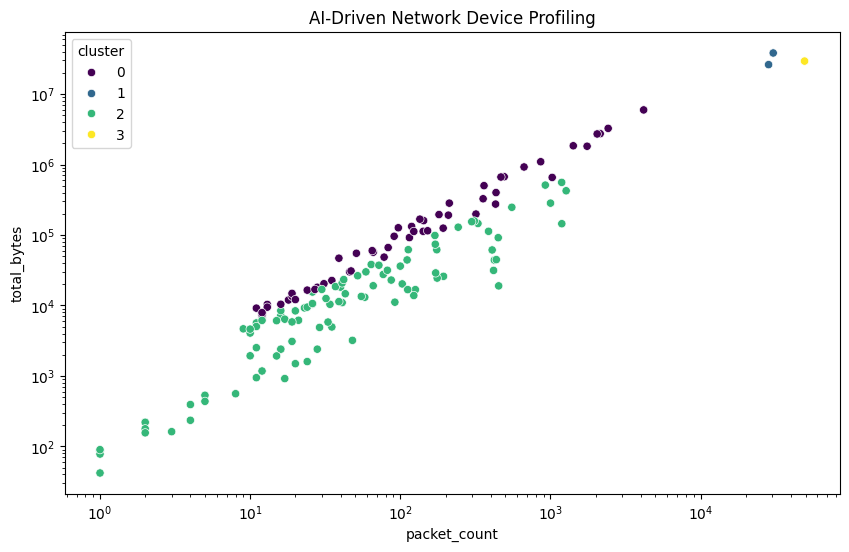

In [5]:
import sqlite3
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


# Connect to DB and Load Data
conn = sqlite3.connect('network_analysis.db')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')
df.columns = [c.replace(' ', '_').replace('.', '') for c in df.columns]
df.to_sql('traffic', conn, if_exists='replace', index=False)

# SQL Aggregation (Profiling Methodology)
query = """
SELECT Source, SUM(Length) as total_bytes, COUNT(*) as packet_count,
       AVG(Length) as avg_packet_len, COUNT(DISTINCT Destination) as unique_destinations
FROM traffic GROUP BY Source
"""
profiles = pd.read_sql(query, conn)

# ML Clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(profiles.drop('Source', axis=1))
profiles['cluster'] = KMeans(n_clusters=4, random_state=42).fit_predict(features_scaled)

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=profiles, x='packet_count', y='total_bytes', hue='cluster', palette='viridis')
plt.yscale('log')
plt.xscale('log')
plt.title('AI-Driven Network Device Profiling')
plt.show()